# Activation Functions

An activation function is a mathematical equation attached to each neuron in an artificial neural network that determines whether the neuron should be activated ("fired") or not. It takes the weighted sum of inputs (plus a bias) from the previous layer and transforms it into the output for the next layer.

In simpler terms, it decides **how important the incoming information is** and controls the output that a neuron passes forward. **They are used to capture non-linearity in the data.**

Why are they important? The most crucial role of an activation function is to introduce **non-linearity** into the network.

- Without non-linear activation functions, a neural network, no matter how many layers it has, would behave just like a single-layer linear regression model. It would only be able to learn linear relationships.
- By adding non-linearity, the network becomes capable of learning complex, intricate patterns in data, such as those found in images, audio, and text.

---



## 1. Sigmoid Function

The Sigmoid function takes any real value as input and outputs values in the range of 0 to 1. The larger the input (more positive), the closer the output value will be to 1.0, whereas the smaller the input (more negative), the closer the output will be to 0.0.

**Formula:**
$$f(y) = \frac{1}{1 + e^{-z}}$$

**When and Where to Use:**
*   **Output Layers:** Primarily used in the output layer of binary classification models (where the output needs to be a probability between 0 and 1 representing the likelihood of belonging to a specific class).
*   **Shallow Networks:** Sometimes used in hidden layers of very shallow networks, but generally avoided in deep networks today.

**Pros:**
*   Outputs a value between 0 and 1, making it perfect for representing probabilities.
*   Smooth gradient, preventing "jumps" in output values.

**Cons:**
*   **Vanishing Gradient Problem if used at hidden layers:** For very high or very low input values, the derivative of the sigmoid is very small (close to 0). During backpropagation, this small gradient is multiplied across layers, causing earlier layers to learn very slowly or not at all in deep networks.
*   **Not Zero-Centered:** The output is always positive, which can make gradient updates less efficient and training slower.
*   Computationally expensive due to the exponential operation ($e^{-x}$).

---

## 2. ReLU (Rectified Linear Unit)

ReLU is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero. It has become the default activation function for many types of neural networks.

**Formula:**
$$f(y) = \max(0, z)$$

**When and Where to Use:**
*   **Hidden Layers:** The standard default choice for hidden layers in almost all types of deep neural networks (CNNs, MLPs).

**Pros:**
*   **Computationally Efficient:** Extremely fast to calculate since it only involves a simple threshold (checking if a number is greater than zero).
*   **Mitigates Vanishing Gradient:** In the positive region ($x > 0$), the gradient is always 1, which helps gradients flow backward during training much better than Sigmoid or Tanh, allowing for the training of deeper networks.
*   **Sparsity:** Because it outputs exactly zero for negative inputs, it creates sparse representations (many neurons are inactive), which can be computationally beneficial and sometimes help with generalization.

**Cons:**
*   **"Dying ReLU" Problem:** If a large gradient flows through a ReLU neuron, it can update the weights in such a way that the neuron will *always* output 0 for any data point going forward. Once a ReLU neuron "dies," its gradient is always 0, and it stops learning entirely.
*   **Not Zero-Centered:** Similar to Sigmoid, the output is only positive or zero.

---

## 3. Tanh (Hyperbolic Tangent)

Tanh is very similar to the Sigmoid function, but its output range is from -1 to 1 instead of 0 to 1. It is mathematically a shifted and stretched version of the Sigmoid.

**Formula:**
$$f(y) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

*(Also equivalent to: $f(y) = 2 \cdot \sigma(2z) - 1$, where $\sigma$ is the sigmoid function)*

**When and Where to Use:**
*   **Hidden Layers:** Often preferred over Sigmoid in hidden layers if a non-ReLU function is desired.
*   **RNNs:** Historically common in Recurrent Neural Networks (RNNs) and LSTMs to keep values contained between -1 and 1 over many time steps.

**Pros:**
*   **Zero-Centered:** Unlike Sigmoid, its output ranges from -1 to 1, meaning the average output is closer to zero. This makes optimization (gradient descent) easier and often leads to faster convergence during training compared to Sigmoid.
*   Stronger gradients than Sigmoid for inputs near zero.

**Cons:**
*   **Vanishing Gradient Problem:** Like Sigmoid, it suffers from vanishing gradients for very large or very small inputs, making it difficult to use in very deep networks.
*   Computationally expensive due to the exponential operations.

---

## 4. Softmax Function

Softmax is a generalization of the Sigmoid function for multiple dimensions. It takes a vector of raw scores (logits) and normalizes them into a probability distribution consisting of probabilities proportional to the exponentials of the input numbers.

**Formula:**
For a vector $\mathbf{z}$ of length $K$, the Softmax for the $i$-th element is:
$$f(y_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**When and Where to Use:**
*   **Output Layer (Multi-class):** Exclusively used in the final output layer of a neural network that handles **multi-class classification** problems (where an input must belong to exactly one out of 3 or more mutually exclusive classes).

**Pros:**
*   **Probability Distribution:** The outputs always sum to exactly 1.0. This makes the output intuitively interpretable as a probability distribution over the different classes.
*   **Highlights the Maximum:** The exponential function ensures that the largest input value gets a significantly higher probability compared to the smaller input values.

**Cons:**
*   **Not for Hidden Layers:** Softmax is designed to produce a probability distribution across multiple nodes, making it unsuitable for use within individual nodes in hidden layers.
*   Sensitive to outliers in the input values due to the exponential function.

The range for the Softmax function is **between 0 and 1** for each individual output value.

Additionally, Softmax has a special property regarding the *entire set* of outputs: **the sum of all the output values produced by a Softmax layer will always equal exactly 1.0.**

### Why is this the case?

Softmax is designed to take an array of raw numbers (logits) and convert them into a **probability distribution**. 

Because it represents probabilities:
1.  **Lower Bound (0):** An event cannot have a negative probability. If the network is absolutely certain a data point does *not* belong to a specific class, the Softmax output for that class will approach `0`.
2.  **Upper Bound (1):** An event cannot have a probability greater than 100%. If the network is absolutely certain a data point *does* belong to a specific class, the Softmax output for that class will approach `1` (and all other classes will approach `0`).
3.  **Summing to 1:** In a multi-class problem (like classifying an image as a cat, dog, or bird), the object must be *one* of those things. Therefore, the total probability across all possible choices must add up to 100% (or `1.0`).

---

### **Sigmoid Function**
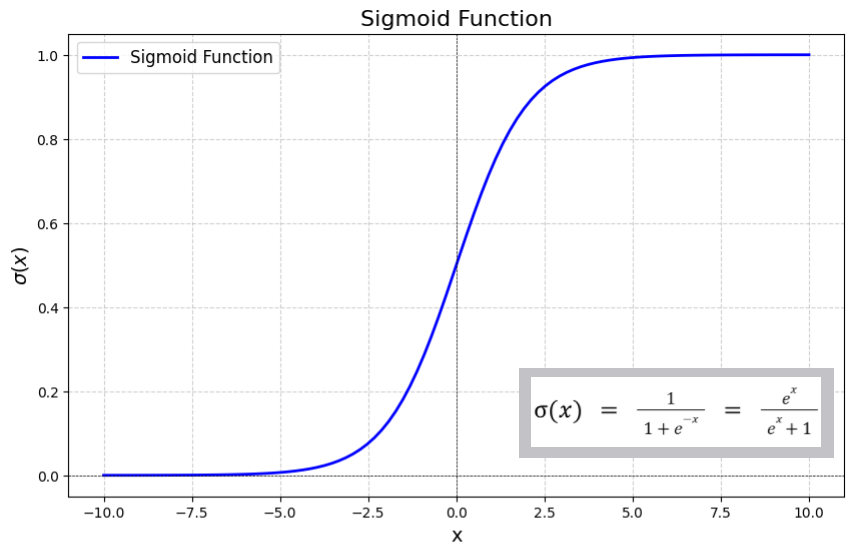


### **TaNH Function**
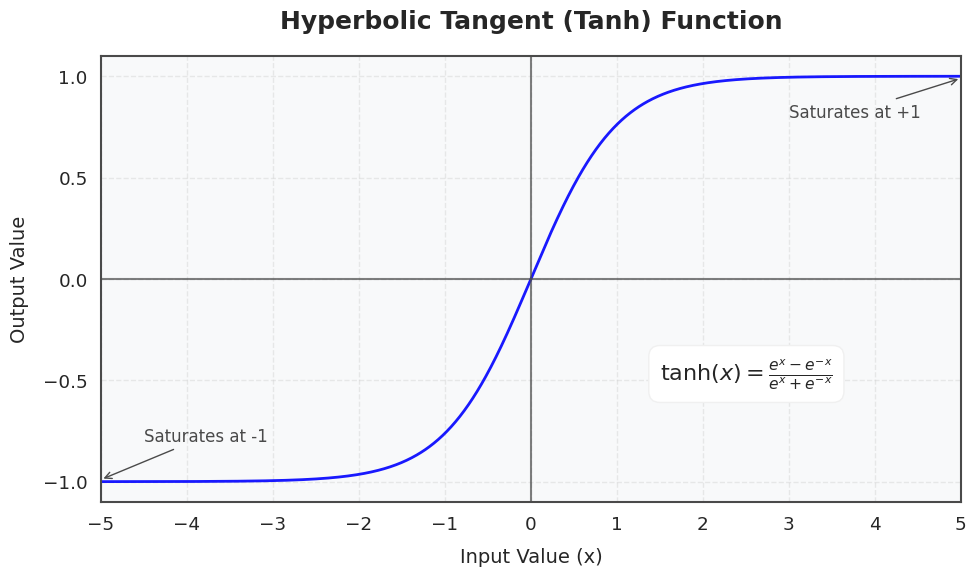


### **ReLU Function**
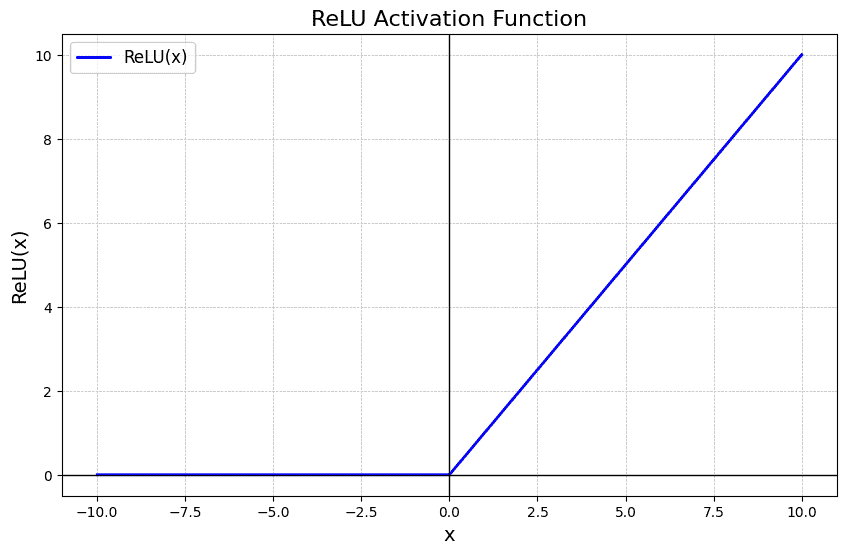


### **SoftMax Function**
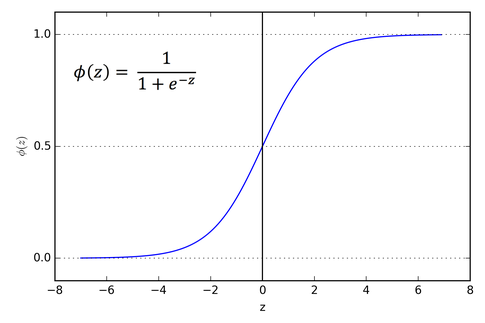
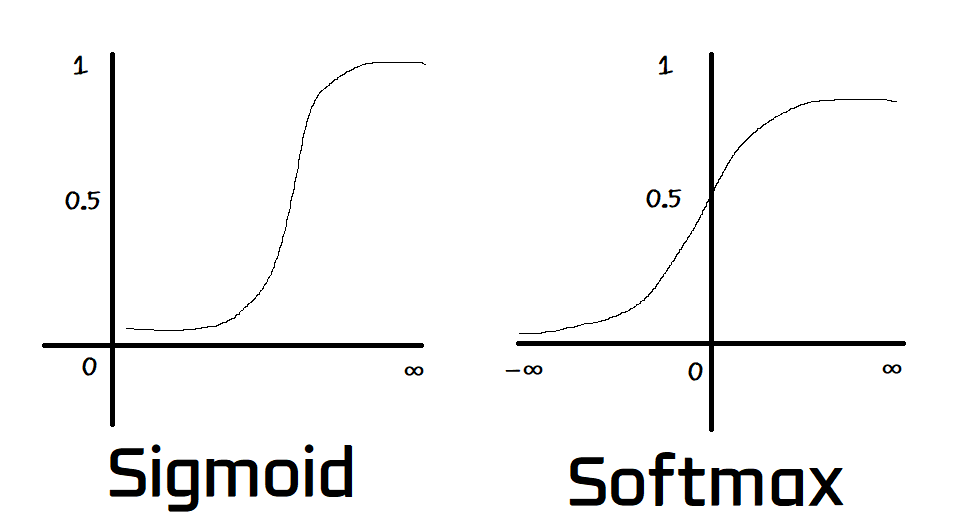

---

# **How does `Sigmoid`, `TaNH`, `ReLU`, ans `softmax` capture non-linearity in the data ???**

### 1. Sigmoid: "Squashing" into a Smooth Curve
Imagine you are trying to separate data points that are grouped in a circular pattern. A straight line (linear function) can only slice straight through the circle; it can't wrap around it.

*   **How it works:** The Sigmoid function takes a straight line (the linear output $Z = WX + b$) and **squashes** it at both ends. It forces very large positive numbers to plateau near $1$, and very large negative numbers to plateau near $0$. 
*   **Capturing Non-Linearity:** This squashing turns a straight line into an 'S'-shaped curve. When you combine many of these 'S'-curves from different neurons in a hidden layer, they can add up to form complex, rounded decision boundaries that can smoothly wrap around clusters of data (like our circle).

### 2. Tanh (Hyperbolic Tangent): "Centered Squashing"
Tanh works exactly the same way as Sigmoid to capture non-linearity, but it has a different shape.

*   **How it works:** Like Sigmoid, it takes a straight line and squashes the extremes. However, it squashes large positive numbers near $+1$ and large negative numbers near $-1$, passing right through $0$ in the middle.
*   **Capturing Non-Linearity:** It creates an 'S'-shaped curve similar to Sigmoid, allowing the network to form rounded, complex boundaries. Because it is centered at zero, it often allows the network to learn these complex shapes faster than Sigmoid during the training process.

### 3. ReLU (Rectified Linear Unit): "Folding the Space"
ReLU doesn't use smooth, squiggly curves like Sigmoid or Tanh. It uses sharp angles.

*   **How it works:** It acts as a hinge. It leaves positive numbers perfectly linear (a straight line), but the moment a number hits zero, it snaps completely flat, blocking all negative numbers. 
*   **Capturing Non-Linearity:** Think of a piece of paper representing your data space. A purely linear model keeps the paper flat. A ReLU neuron acts like a **crease or fold** in that paper. 
    *   One ReLU neuron makes one fold. 
    *   Two ReLU neurons can fold the space into a V-shape.
    *   Hundreds of ReLU neurons across multiple layers create hundreds of tiny folds, allowing the network to bend the data space into highly complex, multi-dimensional origami shapes. By combining enough flat, angled pieces, you can approximate any curved shape perfectly.

### 4. Softmax: "Exaggerating Differences for Classification"
Softmax is unique because it isn't generally used in hidden layers to bend the data space. It is used in the final layer to make a non-linear decision.

*   **How it works:** It takes an array of numbers and applies an exponential function ($e^x$) to each one before dividing them to create probabilities that sum to $1$. 
*   **Capturing Non-Linearity:** The exponential function is highly non-linear. It acts as an **exaggerator**. If the network thinks the data is slightly more likely to be a "cat" (score of $4.0$) than a "dog" (score of $2.0$), the exponential math of Softmax will blow up that small linear difference. The "cat" score will become a massive probability (e.g., $88\%$), and the "dog" score will be crushed (e.g., $11\%$). It introduces non-linearity by sharply amplifying the "winner" and suppressing the "losers" to make a clear, confident final decision.

---

# **How Activation Functions Capture Non-Linearity**

To understand how activation functions capture non-linearity, it helps to first look at what happens *without* them.

## The Problem with Linearity

Imagine a neural network without any activation functions. 

1. **The Math:** Every neuron simply takes its inputs ($X$), multiplies them by weights ($W$), and adds a bias ($b$). Mathematically, this is:
   $$y = WX + b$$
   This is the equation of a straight line (or a flat plane in multiple dimensions).

2. **Stacking Layers:** If you stack multiple layers like this, the math simply collapses back into a single linear equation. 
   * **Layer 1:** $y_1 = W_1 X + b_1$
   * **Layer 2:** $y_2 = W_2(y_1) + b_2 = W_2(W_1 X + b_1) + b_2 = (W_2 W_1)X + (W_2 b_1 + b_2)$
   
   Even with 100 layers, the final output is still just a linear combination of the original inputs.

A purely linear network can only draw straight lines (or flat hyperplanes) to separate data. If your data is arranged in a circle, or intertwined like two spirals, a straight line will never be able to separate the classes properly.


## How Activation Functions Introduce Non-Linearity

An activation function is a **non-linear transformation** applied to the linear output ($WX + b$) *before* it gets passed to the next layer. 

Instead of passing $y = WX + b$, we pass $y = f(WX + b)$, where $f$ is the non-linear activation function (like ReLU or Sigmoid).

Here is how different activation functions bend and twist the linear space to capture complex patterns:

### 1. Bending and Curving (Sigmoid / Tanh)
Sigmoid and Tanh functions take a straight, infinite line of numbers and "squash" them into a bounded curve (like an 'S' shape). 
* When you combine many of these squiggly 'S' shapes together across multiple neurons and layers, the network can mold its decision boundary into complex curves, circles, and irregular shapes to perfectly wrap around the data points.

### 2. Folding and Hinging (ReLU)
ReLU ($f(x) = \max(0, x)$) seems almost too simple—it just replaces negative numbers with zero. But this sharp "bend" or "hinge" at zero is incredibly powerful.
* Imagine a piece of paper (your linear data space). ReLU acts like a fold in the paper.
* Every single ReLU neuron in a hidden layer creates a new "fold" in the data space. 
* By combining thousands of these folds across multiple layers, the network can approximate *any* complex, curvy shape—just like how you can create a smooth-looking curved origami shape by making hundreds of tiny, straight folds.


## Summary: The Universal Approximation Theorem

Because activation functions introduce these bends, squashes, and folds, neural networks gain a mathematical property described by the **Universal Approximation Theorem**. 

This theorem states that a neural network with at least one hidden layer and a non-linear activation function can theoretically approximate *any* continuous mathematical function, no matter how complex or jagged. The activation functions are the tools that allow the network to warp the straight lines of the input data into whatever complex shapes are needed to solve the problem.

---

# **The Range and Working of ReLU**

While Sigmoid is bounded between $[0, 1]$ and Tanh is bounded between $[-1, 1]$, **ReLU ranges from $0$ to positive infinity ($[0, \infty)$).**

*   The minimum possible output is $0$.
*   There is no maximum possible output; the positive side is completely unbounded.


### How ReLU Works

ReLU stands for **Rectified Linear Unit**. "Rectified" is an electrical engineering term for a component (like a diode) that only allows current to flow in one direction. ReLU does exactly that with numbers.

The mathematical formula is incredibly simple:
$$f(y) = \max(0, z)$$

In plain English, this means:
*   **If the input ($y$) is positive**, the output is exactly the same as the input. (It lets the signal pass through unchanged).
*   **If the input ($y$) is negative or zero**, the output is exactly $0$. (It blocks the signal).


### A Math Example

Let's imagine a single neuron in a neural network. 
*   It receives three inputs: $z_1$, $z_2$, and $z_3$.
*   It has three corresponding weights: $W_1$, $W_2$, and $W_3$.
*   It has a bias: $b$.

Let's assign some random numbers:
*   **Inputs:** $z_1 = 2$, $z_2 = -1$, $z_3 = 4$
*   **Weights:** $W_1 = 0.5$, $W_2 = 2.0$, $W_3 = -1.5$
*   **Bias:** $b = 1.0$

**Step 1: Calculate the Linear Sum ($Z$)**
First, the neuron calculates the weighted sum of its inputs plus the bias.
$$Z = (z_1 \cdot W_1) + (z_2 \cdot W_2) + (z_3 \cdot W_3) + b$$
$$Z = (2 \cdot 0.5) + (-1 \cdot 2.0) + (4 \cdot -1.5) + 1.0$$
$$Z = (1.0) - (2.0) - (6.0) + 1.0$$
$$Z = -6.0$$

**Step 2: Apply the ReLU Activation Function**
Now, the neuron applies the ReLU function to the linear sum ($Z$).
$$\text{Output} = \text{ReLU}(Z)$$
$$\text{Output} = \max(0, -6.0)$$
$$\text{Output} = 0$$

Because the linear sum was negative, the ReLU function blocked it and outputted $0$. This neuron is considered "inactive" or "turned off" for this specific set of inputs.

**What if the inputs were different?**
Let's say the weights changed during training, and the new linear sum ($Z$) calculated in Step 1 was **$4.5$**.

$$\text{Output} = \text{ReLU}(4.5)$$
$$\text{Output} = \max(0, 4.5)$$
$$\text{Output} = 4.5$$

Because the input was positive, ReLU simply let the number pass through untouched. 

### Why is this good?
This simplicity is ReLU's superpower. The math $\max(0, x)$ is extremely fast for computers to calculate compared to the complex exponential math ($e^x$) required for Sigmoid or Tanh. Because neural networks perform this calculation millions or billions of times per second, ReLU dramatically speeds up the training process.